Keras use in semantic segmentation for image analysis.

In [42]:
import os
import numpy as np
import cv2
import glob as glob
import pathlib
import random
import matplotlib.pyplot as plt

import zipfile
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.utils import image_dataset_from_directory

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from dataclasses import dataclass

from zipfile import ZipFile
from urllib.request import urlretrieve

from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Activation
from keras.datasets.mnist import load_data

import json
import shutil
import pandas as pd

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import tensorflow_hub as hub
from matplotlib.patches import Rectangle

from zipfile import ZipFile
from urllib.request import urlretrieve

import warnings
import logging
import absl

# Filter absl warnings
warnings.filterwarnings("ignore", module="absl")

# Capture all warnings in the logging system
logging.captureWarnings(True)

# Set the absl logger level to 'error' to suppress warnings
absl_logger = logging.getLogger("absl")
absl_logger.setLevel(logging.ERROR)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
SEED_VALUE = 41

# Fix seed to make training deterministic.
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

Import Kaggle dataset Hrnet.

In [3]:
KAGGLE_PATH = "/root/.kaggle"
if os.path.exists(KAGGLE_PATH):
  !rm -r "$KAGGLE_PATH"

!mkdir "$KAGGLE_PATH"
!touch "$KAGGLE_PATH/kaggle.json"

# https://www.kaggle.com/
api_token = {"username":"Colab_Keras","key":"KGAT_6c5e3427714f0b3f5fe56de3de7aa623"}

with open(KAGGLE_PATH+'/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sadhliroomyprime/football-semantic-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'football-semantic-segmentation' dataset.
Path to dataset files: /kaggle/input/football-semantic-segmentation


Extracting images from directory files.

In [5]:
# Print the contents of the downloaded directory to debug the missing file
print(f"Contents of the downloaded directory '{path}':")
!ls -F "{path}"

# Create a directory to extract the contents
# The path from kagglehub.model_download is a read-only directory.
# We need to create the directory in a writable location, such as /content/.
extracted_dir = os.path.join("/content", "Football_Images")
os.makedirs(extracted_dir, exist_ok=True)

# Extract the tar.gz file
# This part might be redundant if kagglehub.dataset_download already extracted it.
# We need to verify the file structure first.

print(f"Dataset extracted to: {extracted_dir}")

Contents of the downloaded directory '/kaggle/input/football-semantic-segmentation':
'About Acme AI.txt'
'COCO_Football Pixel.json'
 images/
'www.acmeai.tech ODataset 3 - Football Semantic Segmentation.pdf'
Dataset extracted to: /content/Football_Images


Print sample images from the file.

In [6]:
image_paths = sorted(glob.glob(os.path.join(path, "images", "*.png")))

if not image_paths:
    print(f"No images found in {os.path.join(path, 'images')}. Please verify the directory structure.")
else:
    for idx in range(len(image_paths)):
        print(image_paths[idx])


/kaggle/input/football-semantic-segmentation/images/Frame 1  (1).jpg___fuse.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (1).jpg___save.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (10).jpg___fuse.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (10).jpg___save.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (100).jpg___fuse.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (100).jpg___save.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (11).jpg___fuse.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (11).jpg___save.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (12).jpg___fuse.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (12).jpg___save.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (13).jpg___fuse.png
/kaggle/input/football-semantic-segmentation/images/Frame 1  (13).jpg___save.png
/kaggle/input/football-seman

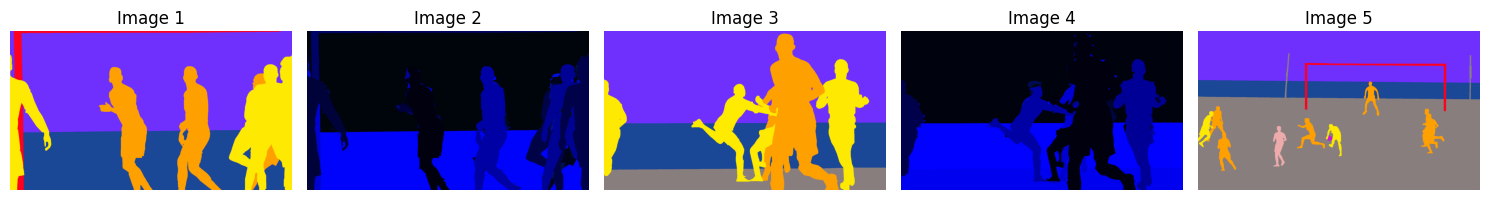

In [7]:
num_images_to_display = 5

plt.figure(figsize=(15, 5))
for i in range(min(num_images_to_display, len(image_paths))):
    img_path = image_paths[i]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Define the 11 classes of the Football dataset from Kaggle.

In [57]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Original class names
class_names_mapping = {
    0:"Goal Bar",
    1:"Referee",
    2:"Advertisement",
    3:"Ground",
    4:"Ball",
    5:"Coaches & Officials",
    6:"Audience",
    7:"Goalkeeper A",
    8:"Goalkeeper B",
    9:"Team A",
    10:"Team B"
}

# Generate a colormap with enough distinct colors for our classes
num_classes = len(class_names_mapping)
colors_cmap = plt.get_cmap('tab20', num_classes)

# Create the class_index with colors in the format expected by class_to_rgb
class_index = {}
for class_id, name in class_names_mapping.items():
    rgb_float = colors_cmap(class_id)[:3] # Get R, G, B (ignore alpha) as floats 0-1
    rgb_int = tuple((np.array(rgb_float) * 255).astype(np.uint8)) # Convert to int 0-255
    class_index[class_id] = [rgb_int, name] # Format: [RGB_tuple, 'Class Name']

print("Updated class_index with RGB colors:")
for class_id, data in class_index.items():
    print(f"{class_id}: {data[0]} - {data[1]}")

Updated class_index with RGB colors:
0: (np.uint8(31), np.uint8(119), np.uint8(180)) - Goal Bar
1: (np.uint8(255), np.uint8(127), np.uint8(14)) - Referee
2: (np.uint8(44), np.uint8(160), np.uint8(44)) - Advertisement
3: (np.uint8(214), np.uint8(39), np.uint8(40)) - Ground
4: (np.uint8(148), np.uint8(103), np.uint8(189)) - Ball
5: (np.uint8(140), np.uint8(86), np.uint8(75)) - Coaches & Officials
6: (np.uint8(227), np.uint8(119), np.uint8(194)) - Audience
7: (np.uint8(127), np.uint8(127), np.uint8(127)) - Goalkeeper A
8: (np.uint8(188), np.uint8(189), np.uint8(34)) - Goalkeeper B
9: (np.uint8(23), np.uint8(190), np.uint8(207)) - Team A
10: (np.uint8(158), np.uint8(218), np.uint8(229)) - Team B


Import the kaggle hornet model for training the dataset.

In [19]:
import kagglehub

# Download latest version
model_url = kagglehub.model_download("google/hrnet/tensorFlow2/hrnet-ade20k-hrnetv2-w48")

print("Path to model files:", model_url)

seg_model = hub.load(model_url)
print("\nmodel loaded!")


Path to model files: /kaggle/input/hrnet/tensorflow2/hrnet-ade20k-hrnetv2-w48/1

model loaded!


In [20]:
# Make a prediction using the first image in the list of images.
# Define the target size for the model input based on model documentation.
# The HRNet CamVid model expects input of (batch_size, 512, 512, 3)
IMG_HEIGHT = 512
IMG_WIDTH = 512

# Load the first image from image_paths that corresponds to an original image.
# Original images end with '___save.png' in this dataset structure.
image_file_path_to_predict = None
for p in image_paths:
    if "___save.png" in p:
        image_file_path_to_predict = p
        break

if image_file_path_to_predict is None:
    # If no '___save.png' found, try to use the first available image path
    print("Warning: No '___save.png' found for prediction. Using the first image path found.")
    image_file_path_to_predict = image_paths[0]

# Load the image using OpenCV
original_image_cv = cv2.imread(image_file_path_to_predict)
# Convert BGR to RGB
original_image_rgb = cv2.cvtColor(original_image_cv, cv2.COLOR_BGR2RGB)

# Convert to TensorFlow tensor
image_tensor = tf.convert_to_tensor(original_image_rgb, dtype=tf.float32)

# Preprocess the image: resize and normalize to [0, 1]
resized_image_tensor = tf.image.resize(image_tensor, (IMG_HEIGHT, IMG_WIDTH))
normalized_image_tensor = resized_image_tensor / 255.0

# Add a batch dimension to create a batch of 1 image
images_for_prediction = tf.expand_dims(normalized_image_tensor, axis=0)

# Make a prediction using the loaded model
# For tf.Module objects loaded via hub.load, direct call is common for inference.
pred_mask = seg_model(images_for_prediction)

# The predicted mask has the following shape: [B, H, W, C].
print("Shape of predicted mask:", pred_mask.shape)


Shape of predicted mask: (1, 512, 512, 151)


In [21]:
# Convert tensor to numpy array.
pred_mask = pred_mask.numpy()

# The 1st label is the background class added by the model, but we can remove it for this dataset.
pred_mask = pred_mask[:, :, :, 1:]

# We also need to remove the batch dimension.
pred_mask = np.squeeze(pred_mask)

# Print the shape to confirm: [H, W, C].
print("Shape of predicted mask after removal of batch dimension and background class:", pred_mask.shape)

Shape of predicted mask after removal of batch dimension and background class: (512, 512, 150)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

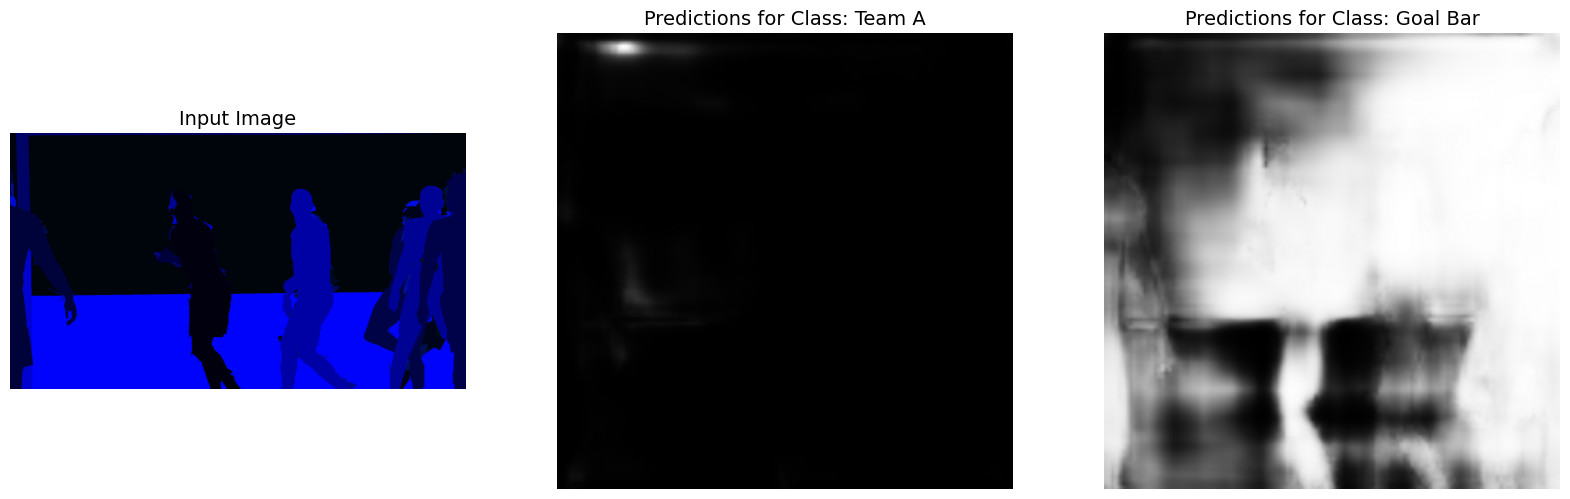

In [43]:
# Each channel in `pred_mask` contains the probabilities that the pixels
# in the original image are associated with the class for that channel.
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.title("Input Image", fontsize=14)
plt.imshow(original_image_rgb)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Predictions for Class: Team A", fontsize=14)
plt.imshow(pred_mask[:, :, 9], cmap="gray") # Class 17 corresponds to the 'Team A' class
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Predictions for Class: Goal Bar", fontsize=14)
plt.imshow(pred_mask[:, :, 0], cmap="gray") # Class 21 corresponds to the 'Goal Bar' class
plt.axis("off")

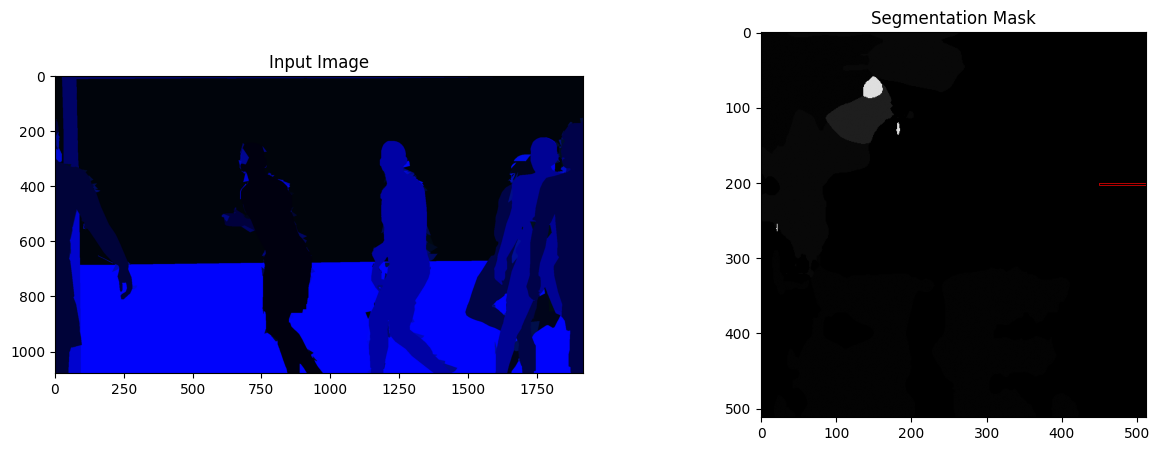

In [44]:
# Assign each pixel in the image a class ID based on the channel that contains the
# highest probability score. This can be implemented using the `argmax` function.
pred_mask_class = np.argmax(pred_mask, axis=-1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.title("Input Image", fontsize=12)
plt.imshow(original_image_rgb)

plt.subplot(1, 2, 2)
plt.title("Segmentation Mask", fontsize=12)
plt.imshow(pred_mask_class, cmap="gray")
plt.gca().add_patch(Rectangle((450, 200), 200, 3, edgecolor="red", facecolor="none", lw=0.5))

In [45]:
# Print the class IDs from the last row in the above image.
print(pred_mask_class[200, 450:650])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [56]:
# Function to convert a single channel mask representation to an RGB mask.
def class_to_rgb(mask_class, class_index):

    # Create RGB channels.
    r_map = np.zeros_like(mask_class).astype(np.uint8)
    g_map = np.zeros_like(mask_class).astype(np.uint8)
    b_map = np.zeros_like(mask_class).astype(np.uint8)

    # Populate RGB color channels based on the color assigned to each class.
    for class_id in range(len(class_index)):
        index = mask_class == class_id
        r_map[index] = class_index[class_id][0][0]
        g_map[index] = class_index[class_id][0][1]
        b_map[index] = class_index[class_id][0][2]

    seg_map_rgb = np.stack([r_map, g_map, b_map], axis=2)

    return seg_map_rgb

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

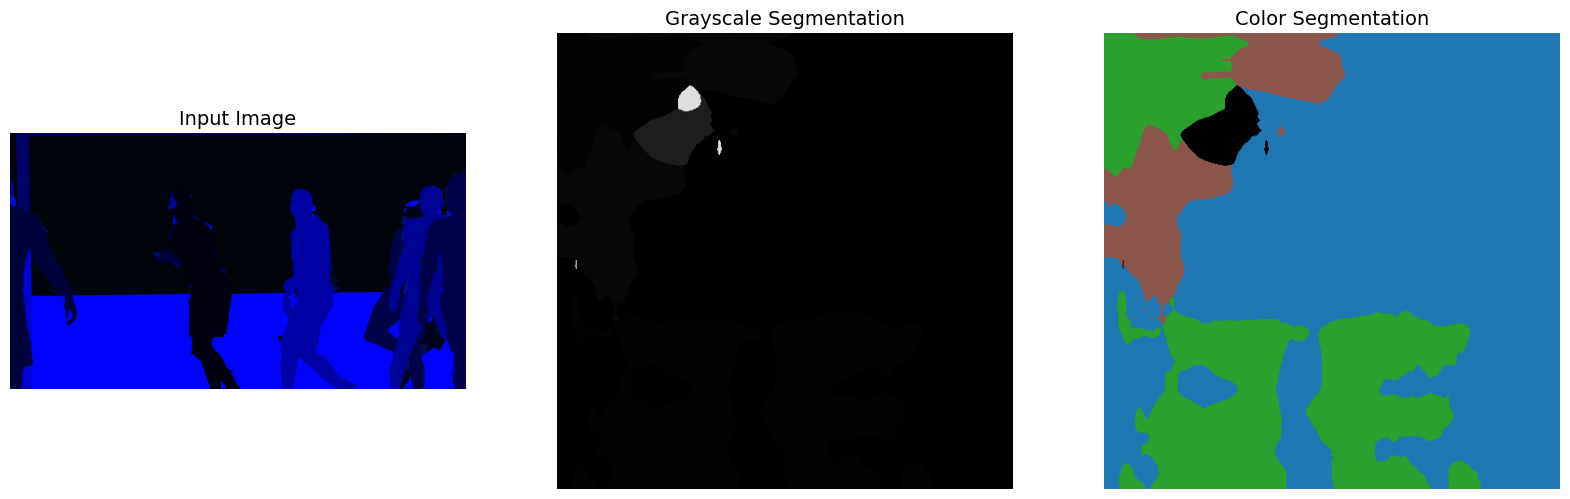

In [60]:
pred_mask_rgb = class_to_rgb(pred_mask_class, class_index)

plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.title("Input Image", fontsize=14)
plt.imshow(np.squeeze(original_image_rgb))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Grayscale Segmentation", fontsize=14)
plt.imshow(pred_mask_class, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Color Segmentation", fontsize=14)
plt.imshow(pred_mask_rgb)
plt.axis("off")

In [61]:
# Function to overlay a segmentation map on top of an RGB image.
def image_overlay(image, seg_map_rgb):

    alpha = 1.0  # Transparency for the original image.
    beta  = 0.6  # Transparency for the segmentation map.
    gamma = 0.0  # Scalar added to each sum.

    image = (image * 255.0).astype(np.uint8)
    seg_map_rgb = cv2.cvtColor(seg_map_rgb, cv2.COLOR_RGB2BGR)

    image = cv2.addWeighted(image, alpha, seg_map_rgb, beta, gamma)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

In [69]:
def run_inference(images, model):
    for img in images:
        # Forward pass through the model (convert the tensor output to a numpy array).
        pred_mask = model.predict(img).numpy()

        # Remove the background class added by the model.
        pred_mask = pred_mask[:, :, :, 1:]

        # Remove the batch dimension.
        pred_mask = np.squeeze(pred_mask)

        # `pred_mask` is a numpy array of shape [H, W, 32] where each channel contains the probability
        # scores associated with a given class. We still need to assign a single class to each pixel
        # which is accomplished using the argmax function across the last dimension to obtain the class labels.
        pred_mask_class = np.argmax(pred_mask, axis=-1)

        # Convert the predicted (class) segmentation map to a color segmentation map.
        pred_mask_rgb = class_to_rgb(pred_mask_class, class_index)

        fig = plt.figure(figsize=(20, 15))

        # Display the original image.
        ax1 = fig.add_subplot(1, 3, 1)
        ax1.imshow(img[0]) # img[0] is still a Tensor here, but imshow can handle it.
        ax1.title.set_text("Input Image")
        plt.axis("off")

        # Display the predicted color segmentation mask.
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.set_title("Predicted Mask")
        ax2.imshow(pred_mask_rgb)
        plt.axis("off")

        # Display the predicted color segmentation mask overlayed on the original image.
        # Convert img[0] to numpy array before passing to image_overlay
        overlayed_image = image_overlay(img[0].numpy(), pred_mask_rgb)
        ax4 = fig.add_subplot(1, 3, 3)
        ax4.set_title("Overlayed Image")
        ax4.imshow(overlayed_image)
        plt.axis("off")

        plt.show()

In [65]:
def plot_color_legend(class_index):
    # Extract colors and labels from class_index dictionary.
    color_array = np.array([[v[0][0], v[0][1], v[0][2]] for v in class_index.values()]).astype(np.uint8)
    class_labels = [val[1] for val in class_index.values()]

    # Calculate suitable grid dimensions for the legend
    num_classes = len(class_index)
    ncols = 6 # Or any reasonable number of columns
    nrows = (num_classes + ncols - 1) // ncols # Calculate rows needed

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3 * nrows))
    plt.subplots_adjust(wspace=0.5, hspace=0.01)

    # Display color legend.
    for i in range(num_classes):
        axis = ax.flat[i]
        axis.imshow(color_array[i][None, None, :])
        axis.set_title(class_labels[i], fontsize=8)
        axis.axis("off")

    # Turn off any unused subplots
    for j in range(num_classes, nrows * ncols):
        ax.flat[j].axis("off")

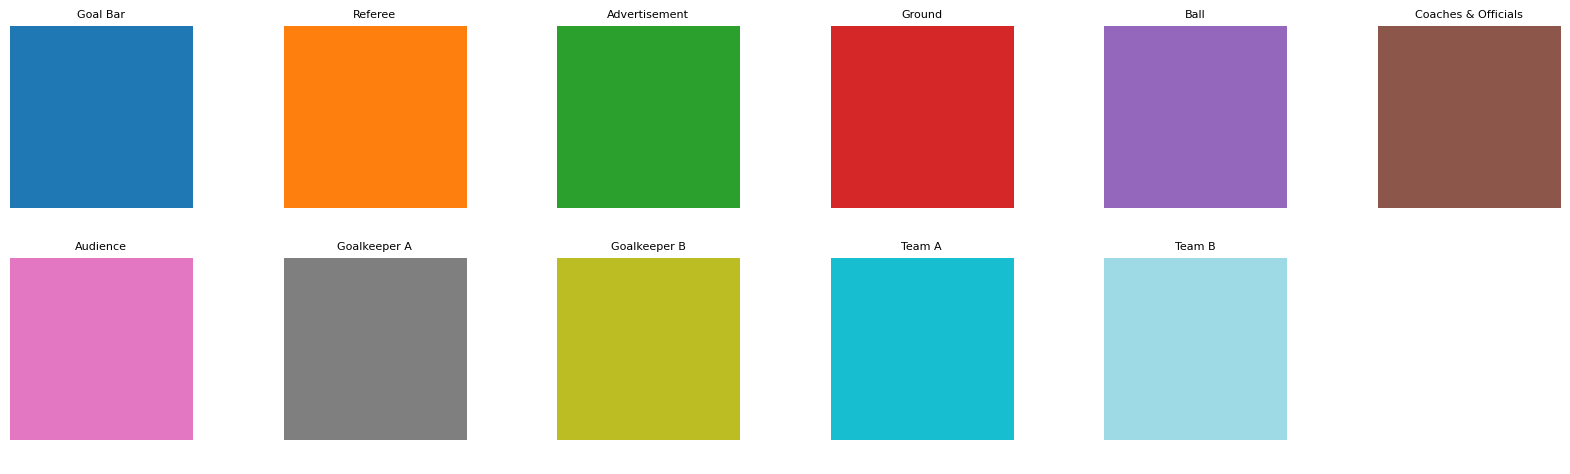

In [66]:
plot_color_legend(class_index)

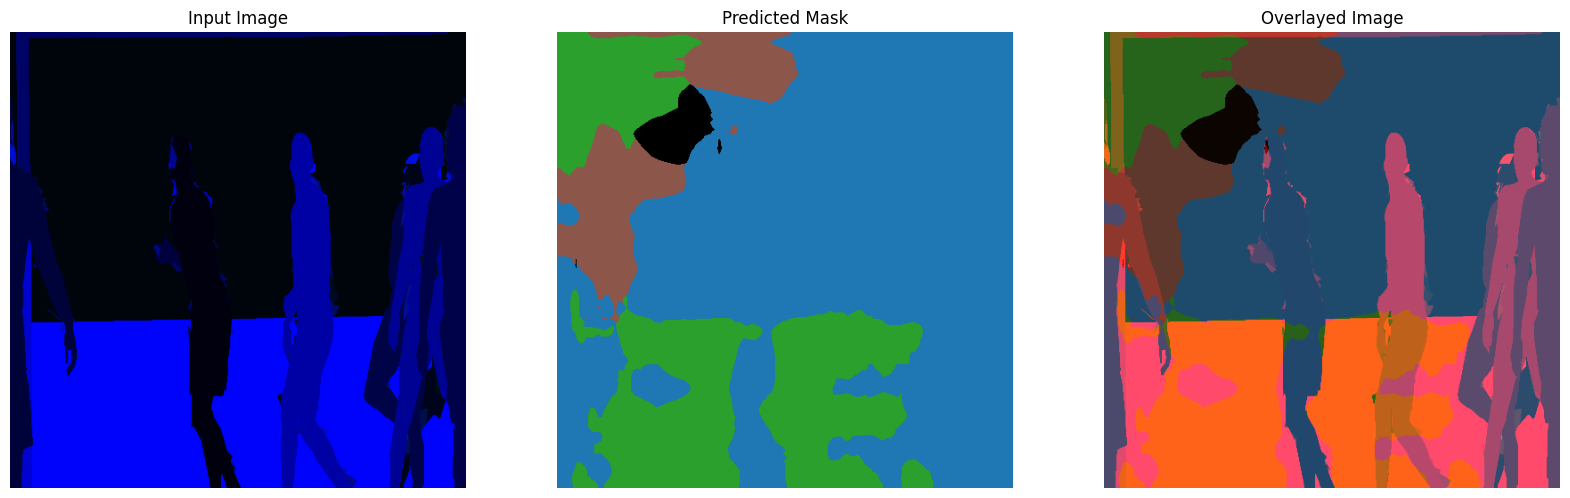

In [71]:
run_inference([images_for_prediction], seg_model)

Example of working with the dataset.

In [72]:
import matplotlib.colors as mcolors

def load_image_and_mask(base_path, image_name):
    image_path = os.path.join(base_path, image_name + "___save.png")
    mask_path = os.path.join(base_path, image_name + "___fuse.png")

    if not os.path.exists(image_path):
        print(f"Image file not found: {image_path}")
        return None, None
    if not os.path.exists(mask_path):
        print(f"Mask file not found: {mask_path}")
        return None, None

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    return image, mask

# Prepare a list of unique image base names
base_image_names = sorted(list(set([os.path.basename(p).replace('___fuse.png', '').replace('___save.png', '') for p in image_paths])))

print(f"Found {len(base_image_names)} unique base image names.")


Found 100 unique base image names.


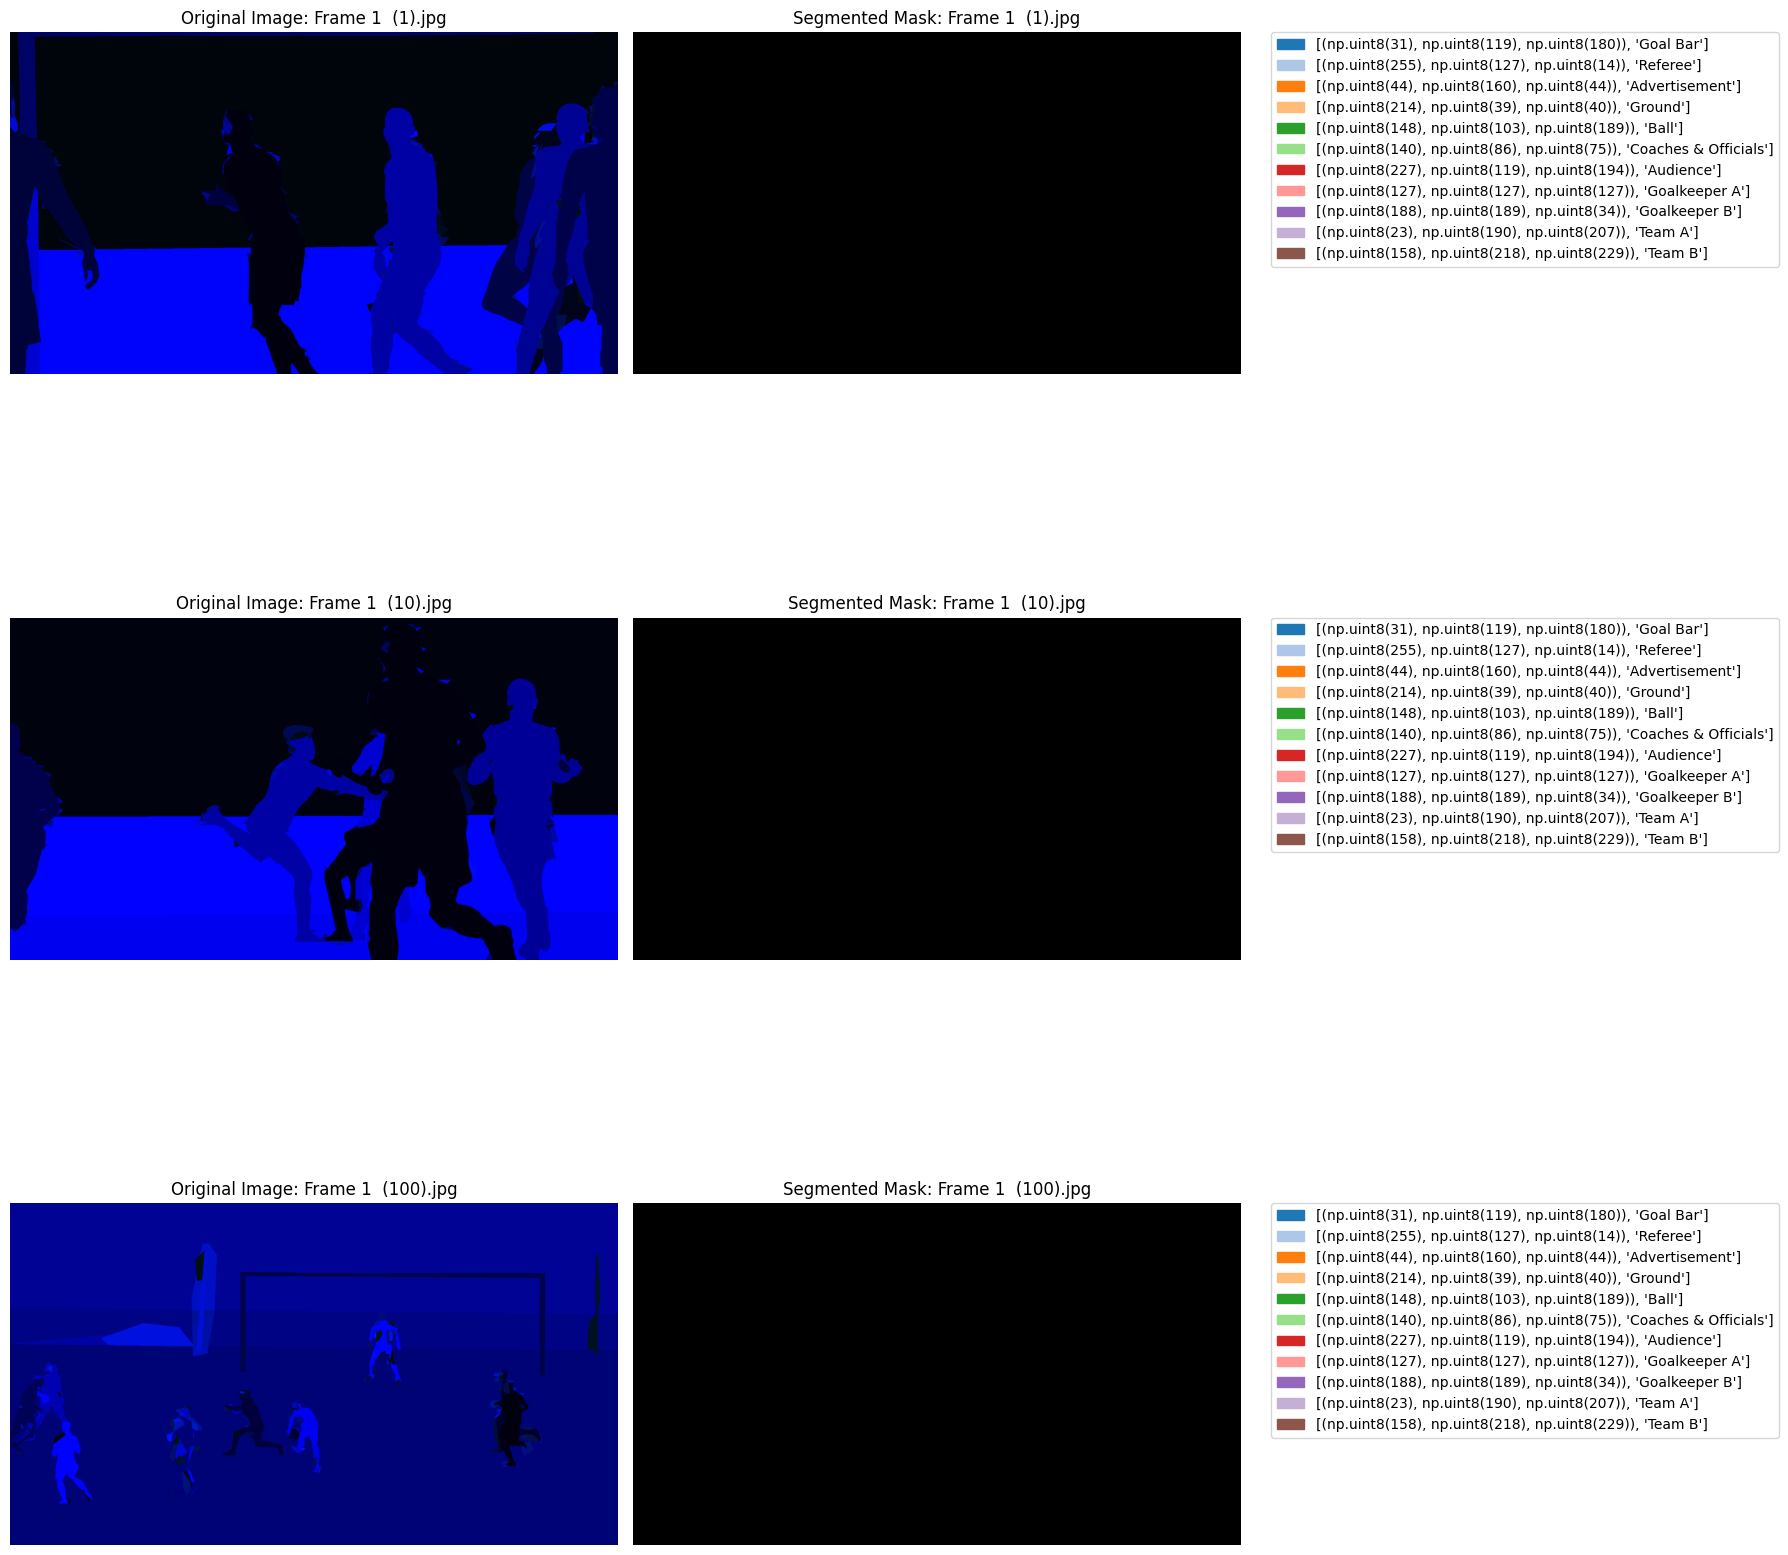

In [73]:
import matplotlib.patches as mpatches
import matplotlib # Added this line

# Generate a colormap for visualization
num_classes = len(class_index)
colors = matplotlib.colormaps.get_cmap('tab20')

def get_colored_mask(mask, class_index, colors):
    colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_id in class_index.keys():
        color = (np.array(colors(class_id)[:3]) * 255).astype(np.uint8)
        colored_mask[mask == class_id] = color
    return colored_mask

# Display some sample images and their masks
num_samples_to_display = 3

plt.figure(figsize=(18, num_samples_to_display * 6))

for i in range(min(num_samples_to_display, len(base_image_names))):
    base_name = base_image_names[i]
    image, mask = load_image_and_mask(os.path.join(path, "images"), base_name)

    if image is not None and mask is not None:
        colored_mask = get_colored_mask(mask, class_index, colors)

        plt.subplot(num_samples_to_display, 2, i * 2 + 1)
        plt.imshow(image)
        plt.title(f"Original Image: {base_name}")
        plt.axis('off')

        plt.subplot(num_samples_to_display, 2, i * 2 + 2)
        plt.imshow(colored_mask)
        plt.title(f"Segmented Mask: {base_name}")
        plt.axis('off')

        # Create a legend
        patches = [mpatches.Patch(color=colors(j), label=class_index[j]) for j in class_index.keys()]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()